In [1]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json 
warnings.filterwarnings('ignore')

master = pd.read_parquet('../data/processed/master_table.parquet')

DROP_COLS = ['SK_ID_CURR', 'TARGET']

X = master.drop(columns=DROP_COLS)
y = master['TARGET']

print(f"Shape: {X.shape}")
print(f"Target rate: {y.mean():.3f}")

Shape: (307511, 164)
Target rate: 0.081


In [2]:
# OOT split by DAYS_DECISION proxy — используем DAYS_BIRTH как временной срез
# В Home Credit нет явной даты, поэтому делаем стратифицированный split 80/20
from sklearn.model_selection import train_test_split

X_train, X_oot, y_train, y_oot = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"OOT:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 164), default rate: 0.081
OOT:   (61503, 164),   default rate: 0.081


In [3]:
# Pre-encode categorical columns before IV calculation
X_train_enc = X_train.copy()

cat_cols = X_train_enc.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X_train_enc[col] = (X_train_enc[col]
                        .fillna('Missing')
                        .astype('category')
                        .cat.codes
                        .astype(float))
    
X_oot_enc = X_oot.copy()
for col in cat_cols:
    X_oot_enc[col] = (X_oot_enc[col]
                      .fillna('Missing')
                      .astype('category')
                      .cat.codes
                      .astype(float))

print(f"Encoded {len(cat_cols)} categorical columns")
print(X_train_enc[cat_cols[:3]].dtypes)  # проверяем что float

def calculate_iv(X, y, features):
    iv_results = []
    for col in features:
        try:
            x_col = X[col].astype('float64')
            ob = OptimalBinning(name=col, dtype='numerical', solver='cp')
            ob.fit(x_col.values, y.values)
            binning_table = ob.binning_table.build()
            iv = binning_table['IV'].iloc[-1]
            iv_results.append({'feature': col, 'iv': round(iv, 4)})
        except Exception as e:
            print(f"ERROR on {col}: {e}")
            iv_results.append({'feature': col, 'iv': 0.0})

    return pd.DataFrame(iv_results).sort_values('iv', ascending=False)

# Теперь передаём закодированный датафрейм
iv_df = calculate_iv(X_train_enc, y_train, X_train_enc.columns.tolist())
print(iv_df.head(20))

Encoded 16 categorical columns
NAME_CONTRACT_TYPE    float64
CODE_GENDER           float64
FLAG_OWN_CAR          float64
dtype: object
                         feature      iv
41                  EXT_SOURCE_3  0.3353
40                  EXT_SOURCE_2  0.3190
39                  EXT_SOURCE_1  0.1480
127      bureau_days_credit_mean  0.1233
16                 DAYS_EMPLOYED  0.1158
8                AMT_GOODS_PRICE  0.0925
15                    DAYS_BIRTH  0.0903
147       inst_late_payment_rate  0.0651
140           prev_approval_rate  0.0627
153                 cc_util_mean  0.0621
6                     AMT_CREDIT  0.0592
10              NAME_INCOME_TYPE  0.0560
134           prev_refused_count  0.0556
121          bureau_active_count  0.0547
29   REGION_RATING_CLIENT_W_CITY  0.0516
145      inst_amt_underpaid_mean  0.0497
28          REGION_RATING_CLIENT  0.0482
123              bureau_debt_sum  0.0482
11           NAME_EDUCATION_TYPE  0.0480
154                  cc_util_max  0.0458


Selected by IV (>= 0.02): 80
Dropped by IV  (<  0.02): 84


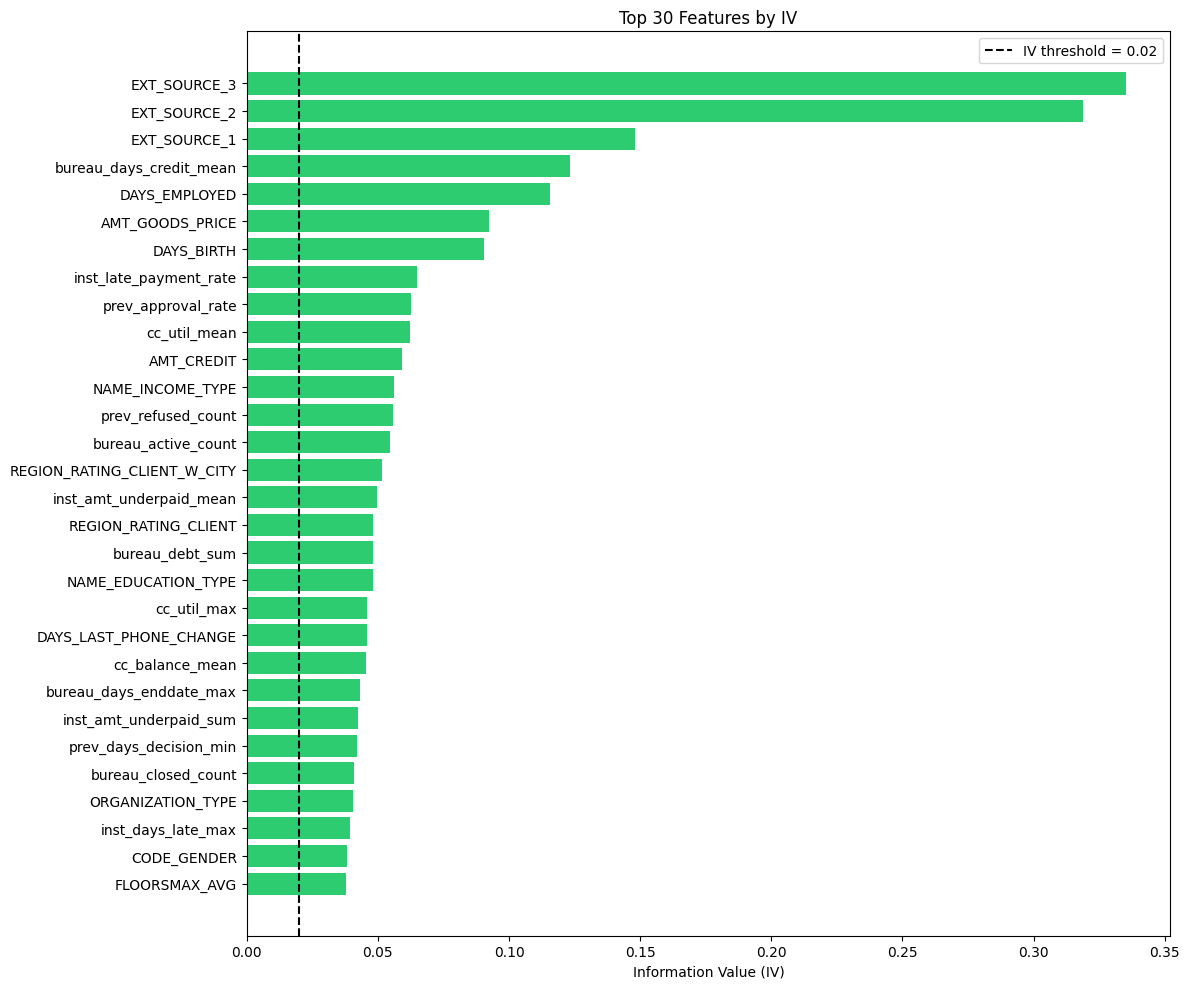

In [4]:
# IV threshold = 0.02 (industry standard minimum)
iv_threshold = 0.02

selected_by_iv = iv_df[iv_df['iv'] >= iv_threshold]['feature'].tolist()
dropped_by_iv  = iv_df[iv_df['iv'] <  iv_threshold]['feature'].tolist()

print(f"Selected by IV (>= {iv_threshold}): {len(selected_by_iv)}")
print(f"Dropped by IV  (<  {iv_threshold}): {len(dropped_by_iv)}")

# Bar chart — top 30 по IV
plt.figure(figsize=(12, 10))
plot_df = iv_df.head(30)
colors = ['#2ecc71' if iv >= iv_threshold else '#e74c3c' for iv in plot_df['iv']]
plt.barh(plot_df['feature'], plot_df['iv'], color=colors)
plt.axvline(x=iv_threshold, color='black', linestyle='--', label=f'IV threshold = {iv_threshold}')
plt.xlabel('Information Value (IV)')
plt.title('Top 30 Features by IV')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Применяем WoE трансформацию только на отобранных признаках
variable_names = selected_by_iv
dtypes = []
for col in variable_names:
    dtypes.append('categorical' if X_train[col].dtype == 'object' else 'numerical')

binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=[c for c, d in zip(variable_names, dtypes) if d == 'categorical']
)

binning_process.fit(X_train_enc[variable_names], y_train)

X_train_woe = binning_process.transform(X_train_enc[variable_names], metric='woe')
X_oot_woe   = binning_process.transform(X_oot_enc[variable_names],   metric='woe')

print(f"WoE transformed train shape: {X_train_woe.shape}")
X_train_woe.head()

WoE transformed train shape: (246008, 80)


,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,bureau_days_credit_mean,DAYS_EMPLOYED,AMT_GOODS_PRICE,DAYS_BIRTH,inst_late_payment_rate,prev_approval_rate,cc_util_mean,...,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,WALLSMATERIAL_MODE,bureau_bb_dpd_months_sum,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,HOUSETYPE_MODE,BASEMENTAREA_MODE,pos_completed_count,cc_payment_rate_mean
181648,0.595479,-0.386393,-0.14801,0.236933,-0.343461,-0.017004,-0.235756,0.194044,0.163627,-0.029022,...,0.123037,0.126762,0.262346,0.090541,0.368281,0.371336,0.159506,0.357655,0.145206,-0.322469
229245,0.000000,0.046047,0.00000,0.000000,-0.309683,0.241728,0.038379,0.194044,0.052525,0.000000,...,0.000000,0.000000,-0.135126,0.000000,0.000000,0.000000,-0.135300,0.000000,0.145206,0.000000
122525,0.547852,-0.093120,0.00000,0.407351,-0.129718,0.047079,0.166426,0.194044,0.163627,0.000000,...,0.123037,0.126762,0.262346,0.090541,0.207618,0.212341,0.159506,0.191863,-0.126858,0.000000
306311,0.014495,0.588388,0.00000,0.507437,-0.129718,-0.277786,0.137161,0.194044,0.163627,0.000000,...,0.123037,0.126762,0.100770,0.090541,0.046394,0.049531,0.159506,0.057394,0.195517,0.000000
300658,0.000000,-0.603444,0.00000,0.000000,-0.258286,-0.043876,-0.446316,0.194044,-0.160931,0.000000,...,0.000000,0.000000,-0.135126,0.000000,0.000000,0.000000,-0.135300,0.000000,-0.126858,0.000000


In [6]:
# Быстрая альтернатива VIF через корреляцию
corr_matrix = X_train_woe.corr().abs()

# Убираем признаки с корреляцией > 0.85
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Dropping {len(drop_corr)} highly correlated features: {drop_corr}")

final_features = [f for f in X_train_woe.columns if f not in drop_corr]
print(f"Features remaining: {len(final_features)}")

Dropping 24 highly correlated features: ['REGION_RATING_CLIENT', 'inst_amt_underpaid_sum', 'FLOORSMAX_MEDI', 'inst_late_payments_count', 'FLOORSMAX_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'APARTMENTS_MODE', 'cc_balance_max', 'ELEVATORS_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'BASEMENTAREA_MEDI', 'HOUSETYPE_MODE', 'BASEMENTAREA_MODE']
Features remaining: 56


### VIF наиболее популярный метод для прооверки признаков на мультиколлинеарность и проверки не только самих признаков по отдельности, но и комбинации признаков. Но из-за того что он очень медленно работает можно воспользовться простой матрицой корреляции которая дает обычно +- такой же результат

In [ ]:
# def calculate_vif(X_woe):
#     """
#     Calculate Variance Inflation Factor for each feature.
#     VIF > 10: high multicollinearity — drop
#     VIF 5-10: moderate — monitor
#     VIF < 5 : acceptable
#     """
#     vif_data = pd.DataFrame()
#     vif_data['feature'] = X_woe.columns
#     vif_data['VIF'] = [
#         variance_inflation_factor(X_woe.values, i)
#         for i in range(X_woe.shape[1])
#     ]
#     return vif_data.sort_values('VIF', ascending=False)

# # Iterative VIF removal
# X_vif = X_train_woe.copy()
# while True:
#     vif = calculate_vif(X_vif)
#     max_vif = vif['VIF'].max()
#     if max_vif > 10:
#         drop_feat = vif.loc[vif['VIF'].idxmax(), 'feature']
#         print(f"Dropping {drop_feat} (VIF={max_vif:.1f})")
#         X_vif = X_vif.drop(columns=[drop_feat])
#     else:
#         break

# final_features = X_vif.columns.tolist()
# print(f"\nFeatures after VIF filter: {len(final_features)}")
# print(calculate_vif(X_vif))

# with open('../models/feature_names.json', 'w') as f:
#     json.dump(final_features, f)

Dropping ENTRANCES_MEDI (VIF=215.0)


KeyboardInterrupt: 

In [8]:
# Быстрая фильтрация через корреляционную матрицу
corr_matrix = X_train_woe.corr().abs()

# Берём верхний треугольник матрицы (без дублей)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Дропаем признаки с корреляцией > 0.85
drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Dropping {len(drop_corr)} highly correlated features:")
print(drop_corr)

final_features = [f for f in X_train_woe.columns if f not in drop_corr]
print(f"\nFeatures remaining: {len(final_features)}")

Dropping 24 highly correlated features:
['REGION_RATING_CLIENT', 'inst_amt_underpaid_sum', 'FLOORSMAX_MEDI', 'inst_late_payments_count', 'FLOORSMAX_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'APARTMENTS_MODE', 'cc_balance_max', 'ELEVATORS_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'BASEMENTAREA_MEDI', 'HOUSETYPE_MODE', 'BASEMENTAREA_MODE']

Features remaining: 56


In [9]:
with open('../models/feature_names.json', 'w') as f:
    json.dump(final_features, f)
print("Saved: feature_names.json")

Saved: feature_names.json


In [ ]:
import os

# Apply final feature selection to both train and OOT
X_train_final = X_train_woe[final_features]
X_oot_final   = X_oot_woe[final_features]

# Save everything needed for modelling notebooks
os.makedirs('../data/processed', exist_ok=True)

X_train_final.assign(TARGET=y_train.values).to_parquet(
    '../data/processed/train_woe.parquet', index=False)

X_oot_final.assign(TARGET=y_oot.values).to_parquet(
    '../data/processed/oot_woe.parquet', index=False)

# Save binning process for scorecard (notebook 07)
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(binning_process, '../models/binning_process.pkl')

print("Saved:")
print(f"  train_woe.parquet : {X_train_final.shape}")
print(f"  oot_woe.parquet   : {X_oot_final.shape}")
print(f"  binning_process.pkl")

Saved:
  train_woe.parquet : (246008, 56)
  oot_woe.parquet   : (61503, 56)
  binning_process.pkl


## Feature Selection Summary

### IV Filtering
| IV Range     | Interpretation | Count |
|---|---|---|
| > 0.3        | Strong         | [вставь] |
| 0.1 – 0.3    | Medium         | [вставь] |
| 0.02 – 0.1   | Weak           | [вставь] |
| < 0.02       | Dropped        | [вставь] |

### VIF Filtering
- Features dropped due to multicollinearity (VIF > 10): [вставь]
- **Final feature count for modelling:** [вставь]

### Key Findings
- Top features by IV confirm EDA results: EXT_SOURCE_1/2/3 dominate
- WoE transformation captures non-linear relationship with default rate
- Missing values handled naturally as separate WoE bins — no imputation needed
